In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import os
    
import numpy as np
import pandas as pd; pd.set_option('display.max_columns', None)
import warnings
warnings.simplefilter(action="ignore")

from scipy.stats import pearsonr, spearmanr

# Config
import seaborn as sns
sns.set_context('notebook', font_scale=1.3)

import pandas as pd; pd.set_option("display.max_columns", None)

import sys;sys.path.append("..")
from dataframes import *
import utils

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [59]:
%matplotlib inline
plt.rcParams['savefig.transparent'] = False  # Ensure no transparency in saved figures
plt.rcParams['figure.facecolor'] = 'white'   # Set the figure background to white
plt.rcParams['axes.facecolor'] = 'white' 

## Functions

In [60]:
def plot_trajectory_hued(
    df,
    pat_id,
    time_col="months_since_first_session",
    group_column="is_proctored",
    ax=None,
):
    ### VARS
    figsize = (10, 5)
    colors = sns.color_palette("colorblind").as_hex()
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Primer scatter
    colors = {'fvc': colors[0], 'svc': colors[3]}
    vars   = {'fvc': 'fvcPercPred_2019', 'svc': 'vcPercPred'}
    for pft in {'fvc','svc'}:
        data_proc = df.query('user_id == @pat_id and pftType == @pft')# and is_proctored == True')
        x1_plot = data_proc[time_col].values
        y1_plot = data_proc[vars[pft]].values
        ax.scatter(
                x1_plot,
                y1_plot,
                color=colors[pft],
                marker='o',
                label=f'{pft.upper()}',
                s=55,
            )
    
    # Regressions
    for pft in {'fvc','svc'}:
        data_proc = df.query('user_id == @pat_id and pftType == @pft')
        x1_fit = data_proc[time_col].values
        y1_fit = data_proc[vars[pft]].values
        
        #########################
        (y_pred, _, _, _, slope, _, intercept, _) = utils.fit_regression(x1_fit, y1_fit, output_all=True)
        #########################
        x1_fit = np.append(x1_fit, 0)
        y_pred = np.append(y_pred, intercept)

        ax.plot(
                x1_fit,
                y_pred,
                color='black',
                linewidth=2,
                label=None,
            )
        
    plt.grid()

def plot_trajectory_panels_fig2(
    df: pd.DataFrame,
    figsize=(35 * 0.5, 20 * 0.5),
    **kwargs,
):
    
    n_cols = 2
    n_rows = 1
    
    fig = plt.figure(figsize=figsize, layout='constrained')
    gs = GridSpec(ncols=n_cols, nrows=n_rows, figure=fig)
    
    #######################
    # Slopes
    single_ax = fig.add_subplot(gs[:, 0])
    col1 = 'slope_fvcPercPred_2019'
    col2 = 'slope_vcPercPred'
    aux = df.groupby('user_id')[[col1, col2]].first() * 30

    corr, p_val = pearsonr(aux[col1], aux[col2])
    corr, p_val = round(corr,3), round(p_val,3)
    print(f'Pearson corr. slopes: {corr} (p-val: ({p_val}))\nN subjects: {(len(aux))}')
    
    corr, p_val = spearmanr(aux[col1], aux[col2])
    corr, p_val = round(corr,3), round(p_val,3)
    print(f'Spearman corr. slopes: {corr} (p-val: ({p_val}))\nN subjects: {(len(aux))}')
    
    single_ax.scatter(aux[col1],
                      aux[col2],
                      edgecolor='k', 
                      alpha=0.7,
                      color='grey',
                    )
    
    single_ax.set_xlabel('Slope FVC % predicted / mo', fontsize=20)
    single_ax.set_ylabel('Slope SVC % predicted / mo', fontsize=20)
    min_val = -7
    max_val = 7
    single_ax.set_xticks([-5, -2.5, 0, 2.5, 5])
    single_ax.set_yticks([-5, -2.5, 0, 2.5, 5])
    single_ax.set_xlim(-5,5)
    single_ax.set_ylim(-5,5)
    single_ax.plot([min_val, max_val], [min_val, max_val], color='grey', linestyle='--', linewidth=2)
    single_ax.grid(True)
    
    #######################
    # Intercepts
    single_ax_2 = fig.add_subplot(gs[:, 1])
    col1 = 'intercept_fvcPercPred_2019'
    col2 = 'intercept_vcPercPred'
    aux = df.groupby('user_id')[[col1, col2]].first()
    
    corr, p_val = pearsonr(aux[col1], aux[col2])
    corr, p_val = round(corr,3), round(p_val,3)
    print(f'Pearson corr. intercepts: {corr} (p-val: ({p_val}))\nN subjects: {(len(aux))}')
    
    corr, p_val = spearmanr(aux[col1], aux[col2])
    corr, p_val = round(corr,3), round(p_val,3)
    print(f'Spearman corr. intercepts: {corr} (p-val: ({p_val}))\nN subjects: {(len(aux))}')
    
    single_ax_2.scatter(aux[col1],
                        aux[col2], 
                        edgecolor='k', 
                        alpha=0.7, 
                        color='grey', 
                        )
    
    single_ax_2.set_xlabel('Intercept FVC % predicted', fontsize=20)
    single_ax_2.set_ylabel('Intercept SVC % predicted', fontsize=20)
    min_val = 30
    max_val = 150
    single_ax_2.plot([min_val, max_val], [min_val, max_val], color='grey', linestyle='--', linewidth=2)
    single_ax_2.grid(True)
    single_ax_2.set_xlim(min_val, max_val)
    single_ax_2.set_ylim(min_val, max_val)
    single_ax_2.set_xticks(range(30, 151, 30))
    single_ax_2.set_yticks(range(30, 151, 30))
    
    #######################
    # Format 
    single_ax.text(0.00, 1.15, 'a', fontsize=30, transform=single_ax.transAxes, va='top', ha='left')
    single_ax_2.text(0.00, 1.15, 'b', fontsize=30, transform=single_ax_2.transAxes, va='top', ha='left')

    return fig

## Run

In [61]:
# Corrida nueva
# Load ZephyrX

### A. Permisive
at_least_efforts_fvc_usable=0
keep_usable_sessions_only=False
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True

### B. Paper-like
at_least_efforts_fvc_usable=3
keep_usable_sessions_only=True
at_least_months_in_study=0
at_least_n_sessions=0
multiply_by_100=True


df_zephyrx_new = load_zephyrx_data(
    at_least_efforts_fvc_usable=at_least_efforts_fvc_usable,
    keep_usable_sessions_only=keep_usable_sessions_only,
    at_least_months_in_study=at_least_months_in_study,
    at_least_n_sessions=at_least_n_sessions,
    multiply_by_100=multiply_by_100,
)
print(f'N pALS: {df_zephyrx_new.user_id.nunique()}, N sessions: {df_zephyrx_new.session_id.nunique()}')

# Keep only one spirometry per session (best one)
df_best_fvc_per_session = df_zephyrx_new.query('pftType=="fvc"').sort_values(['user_id', 'fvcPercPred_2019'], ascending=False).groupby('session_id').first().reset_index()
df_best_svc_per_session = df_zephyrx_new.query('pftType=="svc"').sort_values(['user_id', 'vcPercPred'], ascending=False).groupby('session_id').first().reset_index()
df_zephyrx_new = pd.concat([df_best_fvc_per_session, df_best_svc_per_session])

# Conteo de pacientes, reemplazando el anterior de tirar slopes y demas para que sea mas claro que es lo que hace
all_patients = df_zephyrx_new.user_id.unique()
print(f'All patients: {len(all_patients)}')
all_patients_fvc = df_zephyrx_new.query('pftType=="fvc"').user_id.unique()
all_patients_svc = df_zephyrx_new.query('pftType=="svc"').user_id.unique()
print(f'Patients with FVC: {len(all_patients_fvc)}')
print(f'Patients with SVC: {len(all_patients_svc)}')
all_patients_fvc_svc = all_patients_fvc[np.isin(all_patients_fvc, all_patients_svc)]

print(f'N subjects: {df_zephyrx_new.user_id.nunique()}')
print(f'N sessions with both: {df_zephyrx_new.session_id.nunique()}')
n_fvc = df_zephyrx_new.query('pftType=="fvc"').session_id.nunique()
n_svc = df_zephyrx_new.query('pftType=="svc"').session_id.nunique()
print(f"N FVC sessions: {n_fvc}")
print(f"N SVC sessions: {n_svc}")

--- SCALING PERC PRED VARS TO PERCENTAGE: fvcPercPred_2019, vcPercPred
1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    123, spiro:    288, cols: 108
2 - CRITERIA: n_fvc_atleast_usable >= 3 or vc > 0  subjects:     12, sessions:    113, spiro:    187, cols: 109
--- WARNING computing 'total_timespan' for each user after usability criteria: True
--- TOTAL TIMESPAN: min 0, max 545, mean 336.83
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 12, N sessions: 113
All patients: 12
Patients with FVC: 8
Patients with SVC: 11
N subjects: 12
N sessions with both: 113
N FVC sessions: 61
N SVC sessions: 101


In [62]:
print('Keeping pALS with at least 3 pft in both modalities')
print('n pALS before: ', df_zephyrx_new.user_id.nunique())
n_sessions_per_pft = df_zephyrx_new.groupby('user_id').pftType.value_counts().reset_index()
pals_for_regression = n_sessions_per_pft.groupby('user_id').apply(lambda sub: all(s > 2 for s in sub['count']))
pals_for_regression = pals_for_regression[pals_for_regression].index
df_zephyrx_new = df_zephyrx_new.query('user_id in @pals_for_regression').copy()
print('n pALS after: ', df_zephyrx_new.user_id.nunique())

Keeping pALS with at least 3 pft in both modalities
n pALS before:  12
n pALS after:  8


In [63]:
from scipy.stats import linregress

# Compute per-user linear regression slopes and intercepts for FVC and SVC
all_new_cols = []
for pft, dep_col in [('fvc', 'fvcPercPred_2019'), ('svc', 'vcPercPred')]:
    slope_col = f'slope_{dep_col}'
    intercept_col = f'intercept_{dep_col}'
    all_new_cols.extend([slope_col, intercept_col])
    df_zephyrx_new[slope_col] = np.nan
    df_zephyrx_new[intercept_col] = np.nan

    mask = df_zephyrx_new['pftType'] == pft
    for user_id, grp in df_zephyrx_new[mask].groupby('user_id'):
        x = grp['months_since_first_session'].values
        y = grp[dep_col].values
        if len(x) >= 2:
            slope, intercept, *_ = linregress(x, y)
            df_zephyrx_new.loc[grp.index, slope_col] = slope
            df_zephyrx_new.loc[grp.index, intercept_col] = intercept
df_zephyrx_new = df_zephyrx_new.dropna(subset=all_new_cols)


### Figuras

Pearson corr. slopes: 0.217 (p-val: (0.64))
N subjects: 7
Spearman corr. slopes: -0.4 (p-val: (0.374))
N subjects: 7
Pearson corr. intercepts: -0.771 (p-val: (0.043))
N subjects: 7
Spearman corr. intercepts: -0.762 (p-val: (0.046))
N subjects: 7


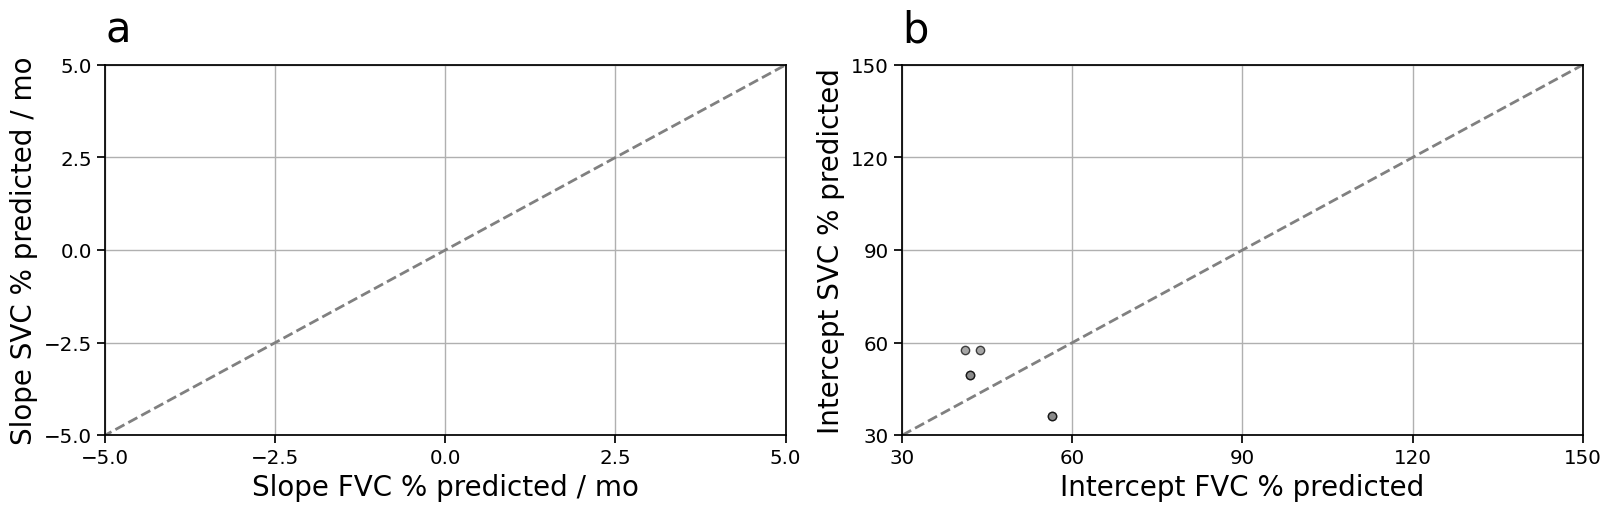

In [64]:
# Figura
fig = plot_trajectory_panels_fig2(df_zephyrx_new, 
                                  figsize=(16, 5))